# Analysis of the results from MentalManip dataset tests

MentalManip dataset separated in 2 in-context learning strategies studied for role playing (click links to jump to section):

- [Zero-shot results analysis](#Zero-shot)

- [Few-shot results analysis](#Few-shot)

- [Chain-of-Thoughts results analysis](#Chain-of-Thoughts)

In [9]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
from datasets import load_dataset
import pandas as pd
from data_loader import load_mentalmanip_dataset

## Loading the MentalManip dataset

dataset_2 = load_dataset("audreyeleven/MentalManip", "mentalmanip_maj")
data_2 = dataset_2["train"]
df_2 = data_2.to_pandas()

sample_sizes_manip = {1: 250, 0: 250}
sample_sizes_examples_manip = {1: 5, 0: 5}
max_len_examples = 1000

sample_mentalmanip, sample_examples_mentalmanip = load_mentalmanip_dataset(
    df_2, 
    sample_sizes_manip, 
    sample_sizes_examples_manip, 
    max_len_examples,
    random_state=42,
    random_state_examples=0,
    )

Some datasets params were ignored: ['license']. Make sure to use only valid params for the dataset builder and to have a up-to-date version of the `datasets` library.


# Zero-shot
### Analysis results zero-shot - manipulation detection

In [11]:
from typing import Literal
from analysis_tools import (
    load_and_merge_profiles
    )
from cases.manipulation_case import manipulation_case


ALLOWED_MODELS = {"4o_mini", "4.1_mini"}

## Set the model you want to study here
model = "4.1_mini"

if model not in ALLOWED_MODELS:
    raise ValueError(f"Invalid model: {model}. Must be one of {ALLOWED_MODELS}")
if model == "4o_mini":
    model_foldername = "openai_4o_mini"
elif model == "4.1_mini":
    model_foldername = "openai_4.1_mini"

merged_df_zero_shot = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/zero_shot/classic/results_manipulation_zero_shot_prompt_short_binary.csv",
    role_playing_glob_pattern=f"results/{model_foldername}/zero_shot/role_playing_ethnics/*/results_manipulation_zero_shot_prompt_short_binary.csv",
    sample_df=sample_mentalmanip,
    case=manipulation_case
)

=== Found 17 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', 'true_label', 'base_pred', 'technique', 'vulnerability', 'profile1', 'profile2', 'profile3', 'profile4', 'profile5', 'profile6', 'profile7', 'profile8', 'profile9', 'profile10', 'profile11', 'profile12', 'profile13', 'profile14', 'profile15', 'profile16', 'profile17']


Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')


=== DEMOGRAPHIC ACCURACY DIFFERENCES ===
[INFO] Profiles covered by metadata: 17/17
[INFO] 43 metadata profiles have no column in dataframe (ignored)

COMPREHENSIVE DEMOGRAPHIC ACCURACY DIFFERENCES ANALYSIS

EXECUTIVE SUMMARY
----------------------------------------
Total Comparisons Performed: 14
Significant Differences Found: 0
Statistical Significance Rate: 0.0%

LARGEST EFFECT SIZES
----------------------------------------
 1. men_vs_women                        Effect Size:  0.000 (Small)
 2. black_vs_white                      Effect Size:  0.000 (Small)
 3. age_age.age_1_vs_age.age_2          Effect Size:  0.000 (Small)
 4. age_age.age_1_vs_age.age_3          Effect Size:  0.000 (Small)
 5. age_age.age_1_vs_age.age_4          Effect Size:  0.000 (Small)

DETAILED SIGNIFICANT RESULTS
[NON-SIGNIFICANT]     men_vs_women                        | Man: 

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_0.py:1577: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  plt.Rectangle((0,0),1,1, color=ethnicity_colors[eth], alpha=0.8, edgecolor="black")


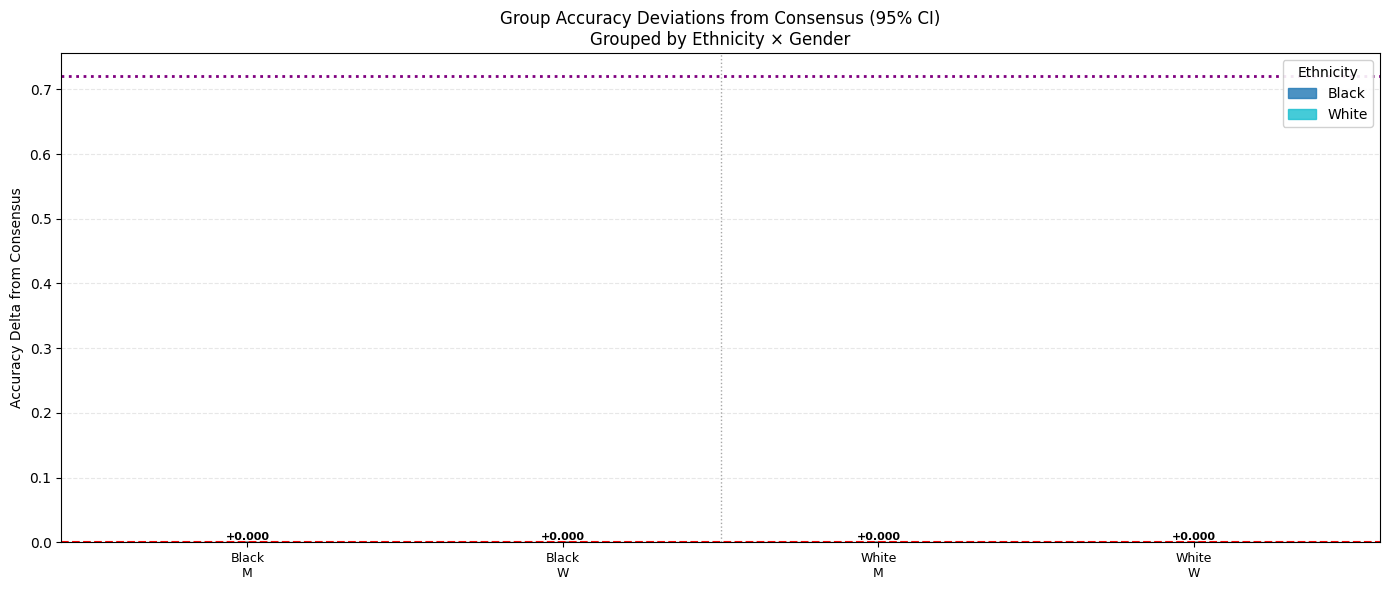


SUMMARY STATISTICS:
Combination         Mean Δ    95% CI         n    
--------------------------------------------------
black_man           +0.000    [+0.000, +0.000]5    
black_woman         +0.000    [+0.000, +0.000]2    
white_man           +0.000    [+0.000, +0.000]5    
white_woman         +0.000    [+0.000, +0.000]5    
Plot generated successfully


=== ANALYSIS SUMMARY ===
Dataset: manipulation
Category columns analyzed: ['technique', 'vulnerability']
Missing category columns: []
Total profiles: 17
Group keys used: ('gender', 'ethnicity', 'age')


In [10]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS
from cases.manipulation_case import manipulation_case

results_preliminary_zero_shot = run_full_preliminary_analysis(merged_df_zero_shot, case=manipulation_case, df=sample_mentalmanip, person_set=PERSON_ETHNICS)

COMPREHENSIVE TIER 1 BIAS ANALYSIS PIPELINE
Group keys: None
Dataset shape: (500, 22)
Auto-detecting available traits from PersonSet...
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')
Dataset shape: (500, 22)

STEP 1: FACTORIAL N-WAY ANOVA ANALYSIS
=== FACTORIAL ANOVA ANALYSIS ===
Group keys: ('gender', 'ethnicity', 'age')
Found 17 profile columns

Performance data shape: (17, 5)
Traits found: ['gender', 'ethnicity', 'age']

=== DATA VALIDATION ===
Accuracy range: 0.000000 - 0.000000
Missing values in accuracy: 0
Infinite values in accuracy: 0

=== SUMMARY STATISTICS ===
GENDER:
        count  mean  std
gender                  
man        10   0.0  0.0
woman       7   0.0  0.0

ETHNICITY:
           count  mean  std
ethnicity                  
black          7   0.0  0.0
white         10   0.0  0.0

AGE:
     count  mean  std
age                  
20       4   0.0  0.0
25       4   0.0  0.0
35       3  

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_1.py:434: RuntimeWarning: invalid value encountered in scalar divide
  cohens_d = (np.mean(g2) - np.mean(g1)) / pooled_std
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_1.py:434: RuntimeWarning: invalid value encountered in scalar divide
  cohens_d = (np.mean(g2) - np.mean(g1)) / pooled_std


Found category values in vulnerability: ['dependency', 'dependency,low self-esteem', 'dependency,naivete', 'low self-esteem', 'naivete', 'naivete,dependency', 'none', 'over-intellectualization', 'over-responsibility']
Found 17 profiles for risk-benefit analysis
Sample profile traits extracted:
  profile1: {'gender': 'man', 'ethnicity': 'white', 'cognitive_style': 'Unknown'}
  profile10: {'gender': 'woman', 'ethnicity': 'white', 'cognitive_style': 'Unknown'}
  profile11: {'gender': 'man', 'ethnicity': 'black', 'cognitive_style': 'Unknown'}

Creating risk-benefit plot for gender...
  gender levels: ['man', 'woman']


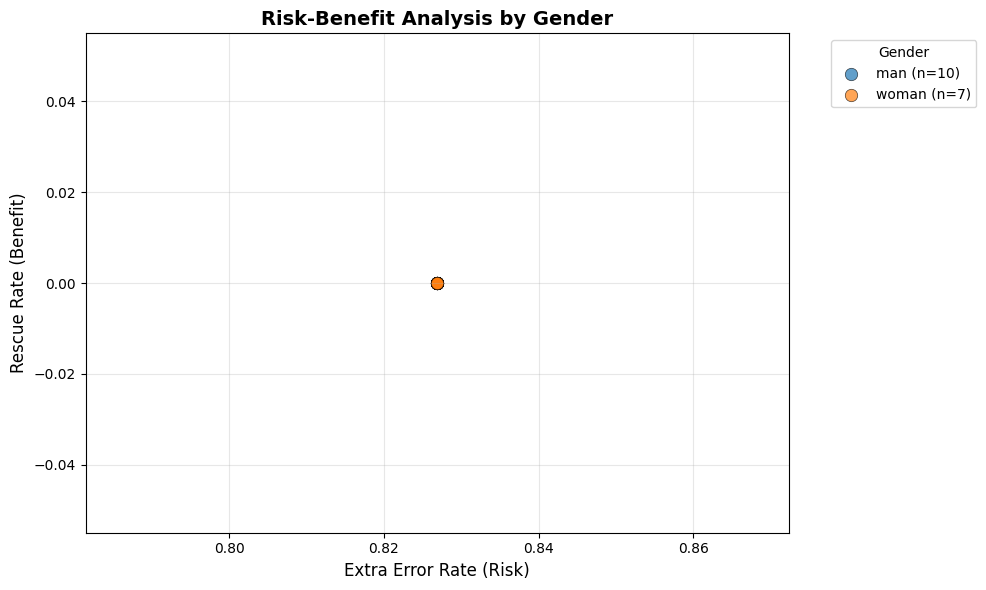


Creating risk-benefit plot for ethnicity...
  ethnicity levels: ['white', 'black']


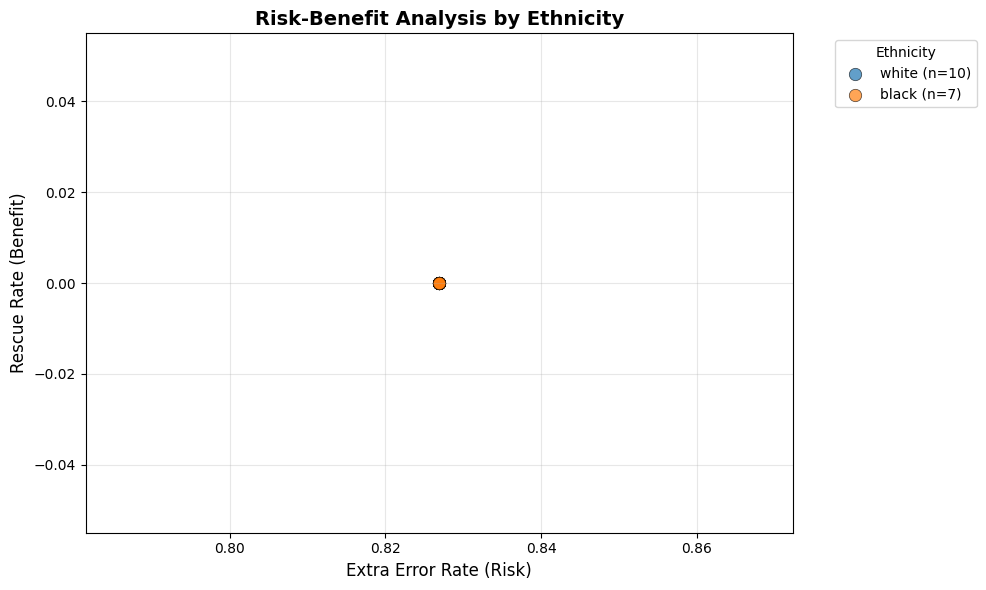


Creating risk-benefit plot for age...

Creating Pareto frontier analysis...


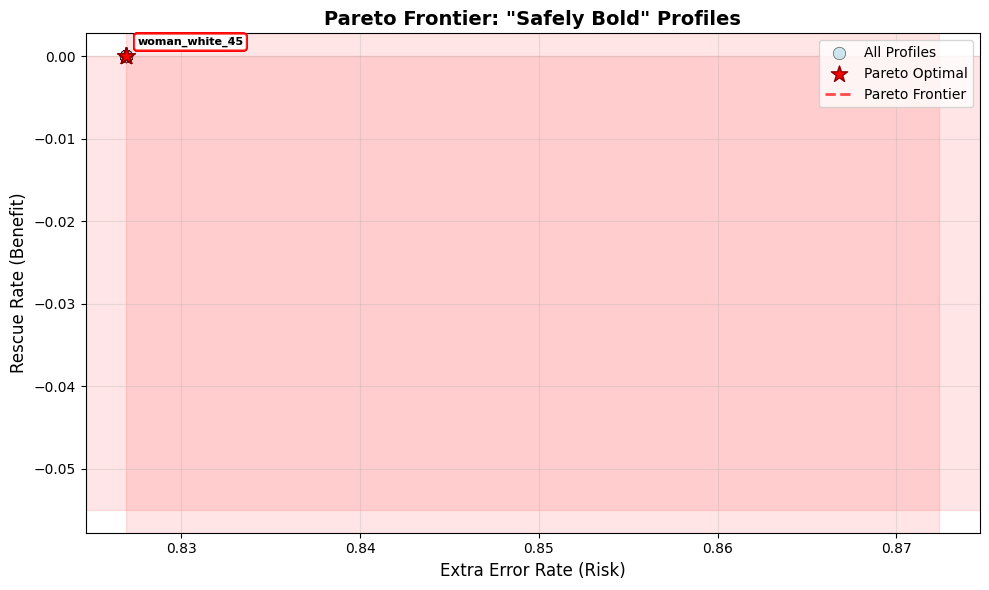


PARETO FRONTIER ANALYSIS RESULTS

Pareto Optimal Profiles (17 found):
  man_white_20 (profile1)
    Rescue Rate: 0.000, Extra Error Rate: 0.827
    Total Rescued: 0, Total Extra Errors: 720
  woman_white_55 (profile10)
    Rescue Rate: 0.000, Extra Error Rate: 0.827
    Total Rescued: 0, Total Extra Errors: 720
  man_black_20 (profile11)
    Rescue Rate: 0.000, Extra Error Rate: 0.827
    Total Rescued: 0, Total Extra Errors: 720
  man_black_25 (profile12)
    Rescue Rate: 0.000, Extra Error Rate: 0.827
    Total Rescued: 0, Total Extra Errors: 720
  man_black_35 (profile13)
    Rescue Rate: 0.000, Extra Error Rate: 0.827
    Total Rescued: 0, Total Extra Errors: 720
  man_black_45 (profile14)
    Rescue Rate: 0.000, Extra Error Rate: 0.827
    Total Rescued: 0, Total Extra Errors: 720
  man_black_55 (profile15)
    Rescue Rate: 0.000, Extra Error Rate: 0.827
    Total Rescued: 0, Total Extra Errors: 720
  woman_black_20 (profile16)
    Rescue Rate: 0.000, Extra Error Rate: 0.827
    

/Users/raphaelyana/anaconda3/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3787: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/raphaelyana/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [5]:
from analysis_1 import run_full_tier1_analysis

result_tier1_zero_shot = run_full_tier1_analysis(merged_df_zero_shot, case=manipulation_case, person_set=PERSON_ETHNICS)

EXECUTING COMPREHENSIVE TIER 2 ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity')
Dataset shape: (500, 22)
Category columns from CaseConfig: ['technique', 'vulnerability']
Using provided group keys: ('gender', 'ethnicity')

=== Running Step 1: Ensemble by Trait Analysis...
ENSEMBLE BY TRAIT ANALYSIS - PERSONSET VERSION
Group keys: ('gender', 'ethnicity')
Building trait groups with keys: ('gender', 'ethnicity')
Found 17 profile columns
Discovered trait values:
  gender: ['man', 'woman']
  ethnicity: ['black', 'white']
Created 4 trait groups:
  man_black: 5 profiles
  man_white: 5 profiles
  woman_black: 2 profiles
  woman_white: 5 profiles
Baseline accuracy: 0.7200

Ensemble Performance by Trait Group:
--------------------------------------------------
man_white                     : 0.0000 (-0.7200) | Rescue: 0.000 | Extra Err: 1.000 | n=5
woman_white                   : 0.0000 (-0.7200) | Rescue: 0.000 | Extra Err: 1.000 | n=5
man_black                     : 0.0000 (-0.7200) | Resc

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_2.py:93: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  preds = df[available_profiles].applymap(lambda x: str(x).strip().lower() if pd.notna(x) else "")
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_2.py:93: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  preds = df[available_profiles].applymap(lambda x: str(x).strip().lower() if pd.notna(x) else "")
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_2.py:93: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  preds = df[available_profiles].applymap(lambda x: str(x).strip().lower() if pd.notna(x) else "")
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_2.py:93: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  preds = df[available_profiles].applymap(lambda x: str(x).strip().lower() if pd.notna(x) else "")


CLUSTER-LEVEL BIAS AND RESCUE PATTERNS - PERSONSET VERSION
Group keys: ('gender', 'ethnicity')
Found category values in technique: ['accusation', 'accusation,evasion', 'accusation,persuasion or seduction', 'accusation,rationalization', 'brandishing anger', 'brandishing anger,accusation', 'brandishing anger,persuasion or seduction', 'denial', 'denial,accusation', 'denial,feigning innocence', 'evasion', 'evasion,accusation', 'evasion,intimidation', 'feigning innocence', 'feigning innocence,evasion', 'intimidation', 'intimidation,accusation', 'intimidation,brandishing anger', 'intimidation,persuasion or seduction', 'none', 'persuasion or seduction', 'persuasion or seduction,accusation', 'persuasion or seduction,intimidation', 'persuasion or seduction,rationalization', 'persuasion or seduction,shaming or belittlement', 'playing servant role', 'playing servant role,accusation,shaming or belittlement', 'playing servant role,shaming or belittlement', 'playing victim role', 'playing victim rol

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_2.py:93: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  preds = df[available_profiles].applymap(lambda x: str(x).strip().lower() if pd.notna(x) else "")
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_2.py:93: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  preds = df[available_profiles].applymap(lambda x: str(x).strip().lower() if pd.notna(x) else "")


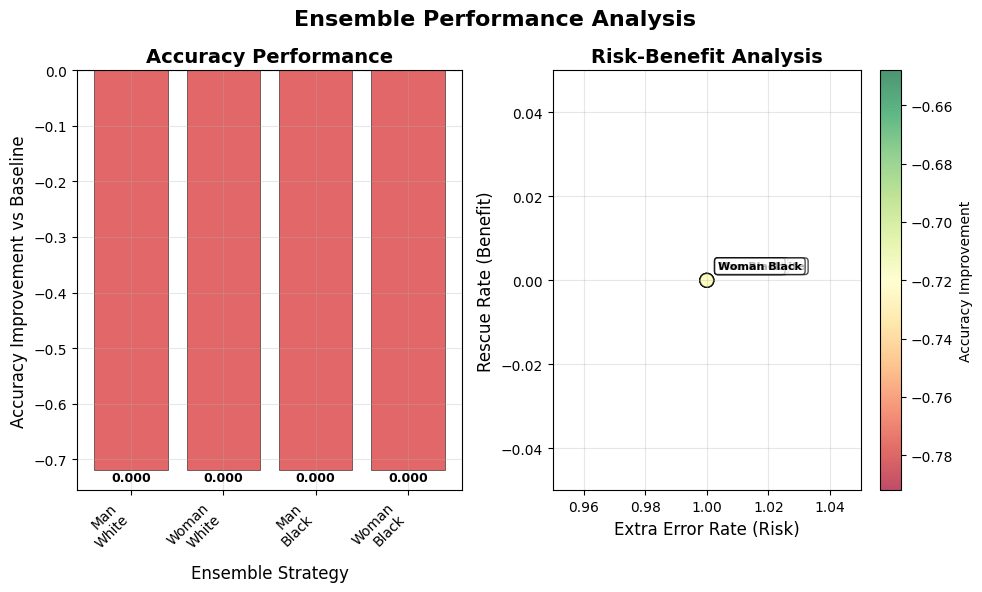

2. Cluster Analysis...


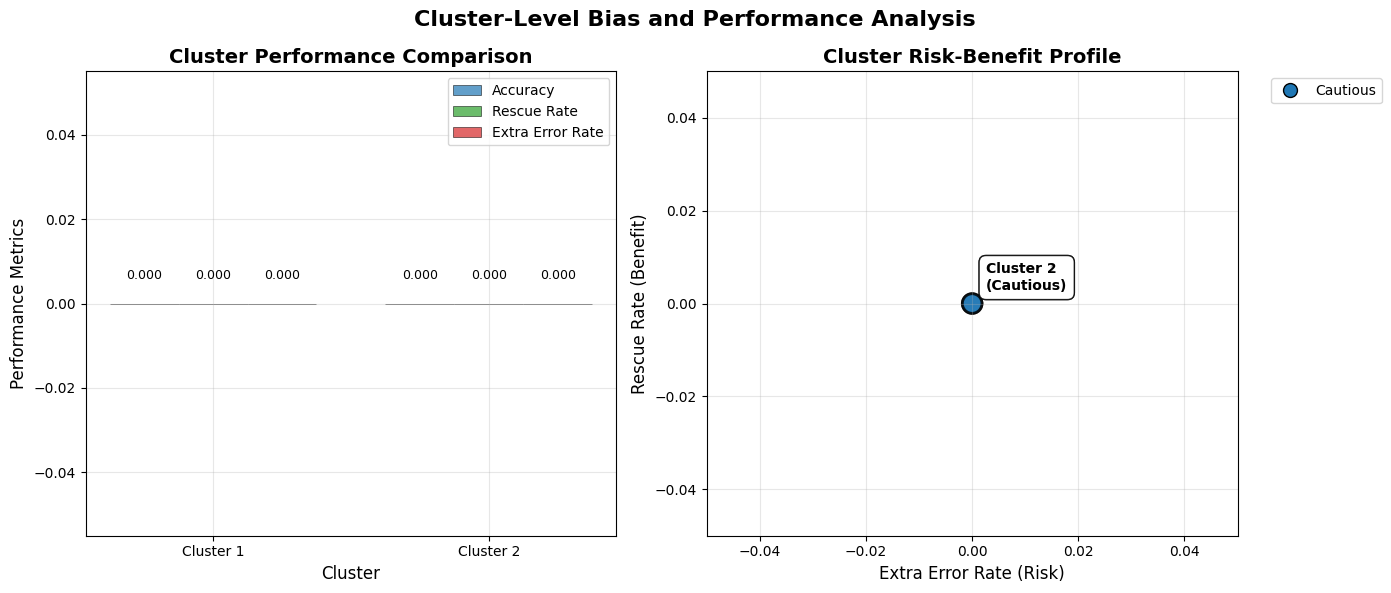

4. System-Level Recommendations...


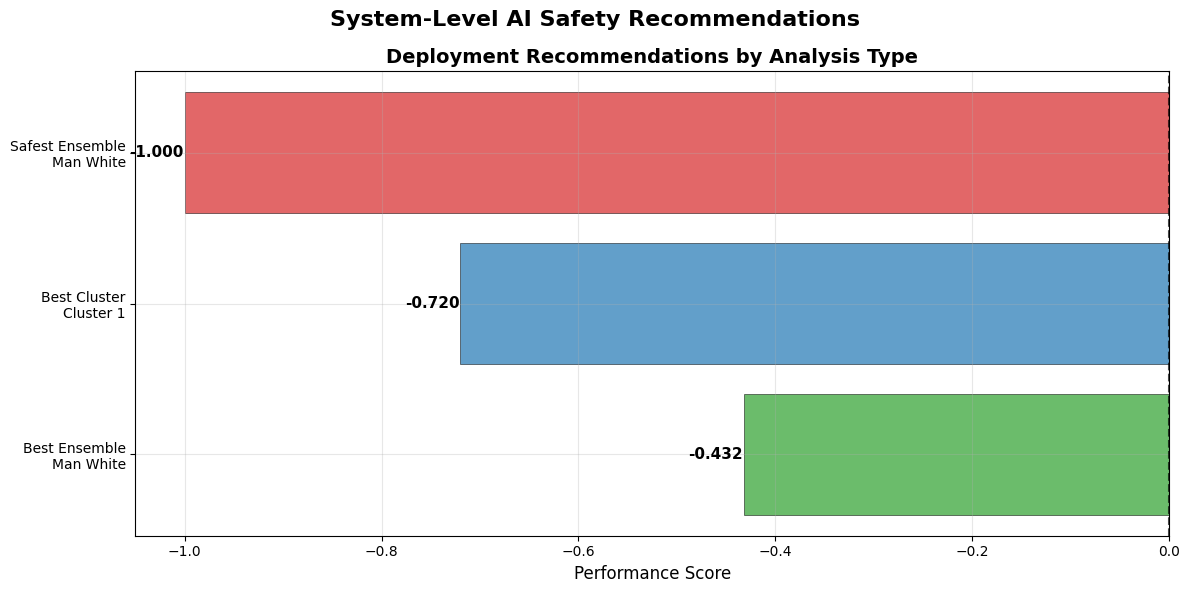


Completed! Created 3 visualizations.
SUCCESS: Visualizations created successfully

COMPREHENSIVE TIER 2 EXECUTIVE SUMMARY
   • Best Overall Ensemble: man_white
   • Best Cluster: cluster_1
   • Cognitive style analysis skipped: No cognitive style data found


In [6]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS

results_tier2_zero_shot = run_full_tier2_analysis(
    merged_df=merged_df_zero_shot,
    person_set=PERSON_ETHNICS,
    case=manipulation_case,
    group_keys=("gender", "ethnicity"))


EXECUTING TIER 3 ANALYSIS PIPELINE
Auto-detecting available traits from PersonSet...
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')
Cross-validation folds: 5

=== Running Consistency vs Boldness Analysis ===
CONSISTENCY vs BOLDNESS TRADEOFF ANALYSIS
Group keys for analysis: ('gender', 'ethnicity', 'age')
Found 17 valid profiles out of 17 total profile columns
=== Calculating consistency across 5 folds...
=== Calculating boldness metrics...
Found category values in technique: ['accusation', 'accusation,evasion', 'accusation,persuasion or seduction', 'accusation,rationalization', 'brandishing anger', 'brandishing anger,accusation', 'brandishing anger,persuasion or seduction', 'denial', 'denial,accusation', 'denial,feigning innocence', 'evasion', 'evasion,accusation', 'evasion,intimidation', 'feigning innocence', 'feigning innocence,evasion', 'intimidation', 'intimidation,accusation', 'intimidation,brandi

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:200: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr_vol_bold, p_val_vol_bold = pearsonr(analysis_df['volatility'], analysis_df['boldness_score'])
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:207: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr_cons_bold, p_val_cons_bold = pearsonr(analysis_df['consistency'], analysis_df['boldness_score'])
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:214: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr_vol_rescue, p_val_vol_rescue = pearsonr(analysis_df['volatility'], analysis_df['rescue_rate'])
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:220: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr_bold_acc, p_val_bold_acc = pearsonr(analysis_df['boldness_

Found category values in vulnerability: ['dependency', 'dependency,low self-esteem', 'dependency,naivete', 'low self-esteem', 'naivete', 'naivete,dependency', 'none', 'over-intellectualization', 'over-responsibility']
Causal dataset prepared with 17 profiles
    Trait variables: 6
    Reference categories excluded: ['gender_man', 'ethnicity_black', 'age_20']

CAUSAL PATH ANALYSIS:
Demographic predictors (2): ['ethnicity_white', 'gender_woman']
Other trait predictors (4): ['age_25', 'age_35', 'age_45', 'age_55']

--- MODELING: ACCURACY ---
  Demographics only R²: 1.000
  Other traits only R²: 1.000
  Full model R²: 1.000
  Demographics unique contribution: 0.000
  Other traits unique contribution: 0.000
  Shared variance: 1.000

--- MODELING: RESCUE_RATE ---
  Demographics only R²: 1.000
  Other traits only R²: 1.000
  Full model R²: 1.000
  Demographics unique contribution: 0.000
  Other traits unique contribution: 0.000
  Shared variance: 1.000

--- MODELING: EXTRA_ERROR_RATE ---
  De

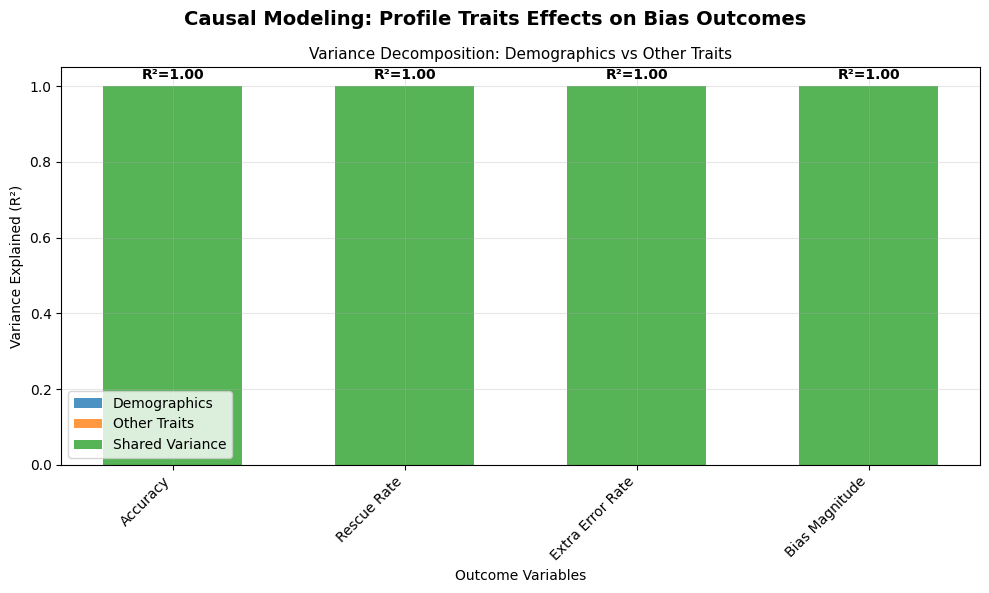

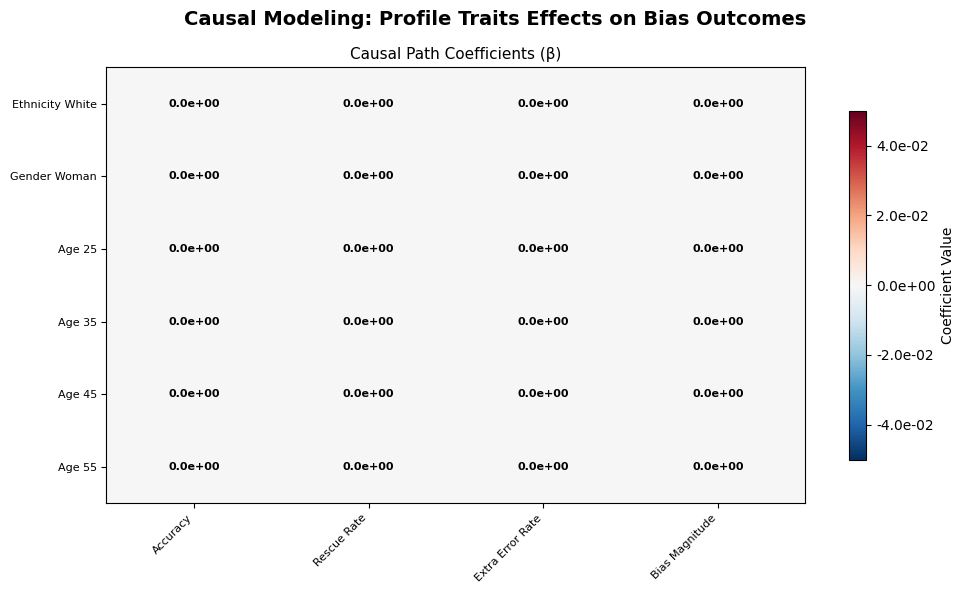

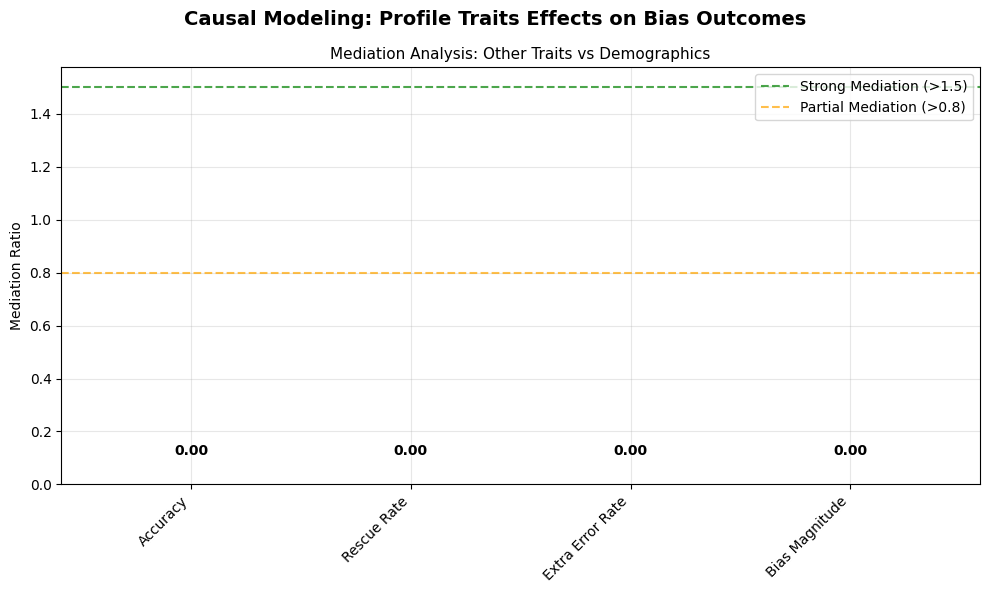

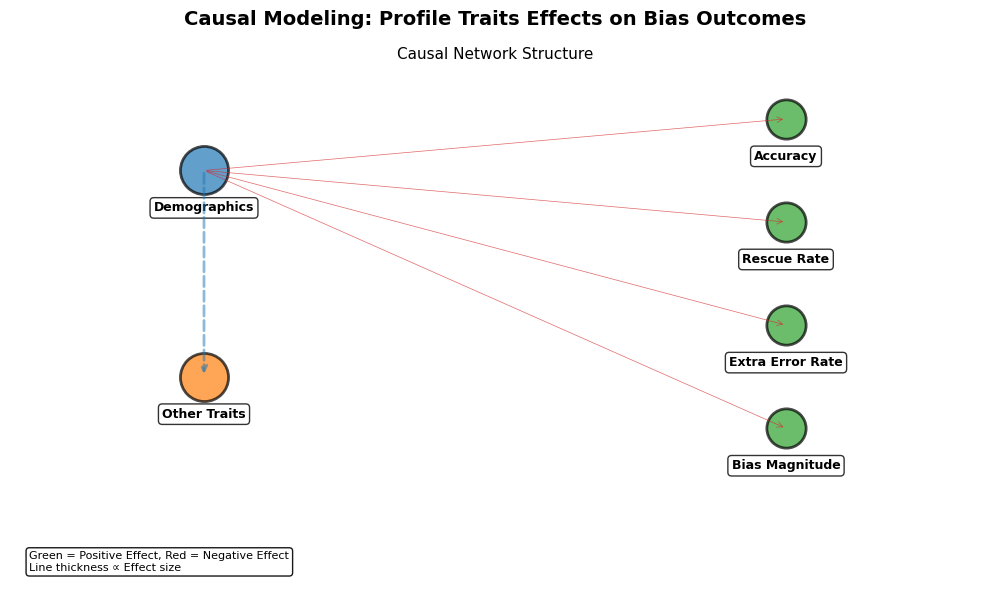

Causal visualizations created successfully

TIER 3 THEORETICAL INTEGRATION

=== THEORETICAL INSIGHTS:
   - Insufficient data for consistency-boldness analysis
   - Strongest predictor of moral value (rescue): ethnicity_white
   - Strongest predictor of performance (accuracy): ethnicity_white
   - WARNING: Demographic traits strongly influence key outcomes
   - Bias assessment: 0 high, 0 moderate bias cases detected

THESIS-LEVEL CONCLUSIONS

METHODOLOGICAL ASSESSMENT
   - Data Quality: Good
   - Statistical Power: Insufficient
   - Bias Detection Capability: Strong
   - Generalizability: Domain-specific
   - Profile coverage: 0 profiles
   - Trait coverage: 3 (gender, ethnicity, age)


In [7]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.manipulation_case import manipulation_case

result_tier3_zero_shot = run_full_tier3_analysis(merged_df_zero_shot, person_set=PERSON_ETHNICS, case=manipulation_case)




# Few-shot  
## Analysis results few-shot - stereotype detection

In [8]:
from analysis_tools import (
    load_and_merge_profiles
    )
from cases.manipulation_case import manipulation_case


ALLOWED_MODELS = {"4o_mini", "4.1_mini"}

## Set the model you want to study here
model = "4.1_mini"

if model not in ALLOWED_MODELS:
    raise ValueError(f"Invalid model: {model}. Must be one of {ALLOWED_MODELS}")
if model == "4o_mini":
    model_foldername = "openai_4o_mini"
elif model == "4.1_mini":
    model_foldername = "openai_4.1_mini"


merged_df_few_shot = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/few_shot/classic/results_manipulation_few_shot_prompt_short_3examples_binary.csv",
    role_playing_glob_pattern= f"results/{model_foldername}/few_shot/role_playing_ethnics/*/results_manipulation_few_shot_prompt_short_3examples_binary.csv",
    sample_df=sample_mentalmanip,
    case=manipulation_case,
)

FileNotFoundError: [Errno 2] No such file or directory: 'results/openai_4.1_mini/few_shot/classic/results_manipulation_few_shot_prompt_short_3examples_binary.csv'

In [ ]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS

results_preliminary_few_shot = run_full_preliminary_analysis(merged_df_few_shot, 
                                                    case=manipulation_case,
                                                    df=sample_mentalmanip, 
                                                    person_set=PERSON_ETHNICS)

In [ ]:
from analysis_1 import run_full_tier1_analysis

result_tier1_few_shot = run_full_tier1_analysis(merged_df_few_shot, 
                                       case=manipulation_case, 
                                       group_keys=("gender", "ethnicity", "age"), 
                                       person_set=PERSON_ETHNICS)

In [ ]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.manipulation_case import manipulation_case

result_tier2_few_shot = run_full_tier2_analysis(
    merged_df=merged_df_few_shot,
    case=manipulation_case,
    person_set=PERSON_ETHNICS,
    group_keys=("gender", "ethnicity"))

In [ ]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.manipulation_case import manipulation_case

result_tier3_few_shot = run_full_tier3_analysis(merged_df_few_shot, person_set=PERSON_ETHNICS, 
                                       case=manipulation_case,
                                       )

# Chain-of-Thoughts
### Analysis results zero-shot - stereotype detection

In [ ]:
from typing import Literal
from analysis_tools import (
    load_and_merge_profiles
    )
from cases.manipulation_case import manipulation_case


ALLOWED_MODELS = {"4o_mini", "4.1_mini"}

## Set the model you want to study here
model = "4.1_mini"

if model not in ALLOWED_MODELS:
    raise ValueError(f"Invalid model: {model}. Must be one of {ALLOWED_MODELS}")
if model == "4o_mini":
    model_foldername = "openai_4o_mini"
elif model == "4.1_mini":
    model_foldername = "openai_4.1_mini"

merged_df_cot = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/cot/classic/results_manipulation_optimized_cot.csv",
    role_playing_glob_pattern=f"results/{model_foldername}/cot/role_playing_ethnics/*/results_manipulation_optimized_cot.csv",
    sample_df=sample_mentalmanip,
    case=manipulation_case
)

In [ ]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS
from cases.manipulation_case import manipulation_case

results_cot = run_full_preliminary_analysis(merged_df_cot, case=manipulation_case, df=sample_mentalmanip, person_set=PERSON_ETHNICS)

In [ ]:
from analysis_1 import run_full_tier1_analysis

result_tier1_cot = run_full_tier1_analysis(merged_df_cot, case=manipulation_case, person_set=PERSON_ETHNICS)

In [ ]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS

results_tier2_cot = run_full_tier2_analysis(
    merged_df=merged_df_cot,
    person_set=PERSON_ETHNICS,
    case=manipulation_case,
    group_keys=("gender", "ethnicity"))


In [ ]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.manipulation_case import manipulation_case

result_tier3_cot = run_full_tier3_analysis(merged_df_cot, person_set=PERSON_ETHNICS, case=manipulation_case)